# TA-ORF → SpatialData

`cpio.read_plate` reads one plate of a Cell Painting Gallery source into a [SpatialData](https://spatialdata.scverse.org) object.
Fields of view become Images, the CellProfiler Nuclei, Cells and Cytoplasm segmentations become Labels, the wells become Shapes, and the well- and cell-level measurements become the `wells` and `cells` Tables.

Objects are Labels rather than Shapes because CellProfiler is pixel-based: it measures on masks, so a polygon would be a lossy conversion.
The gallery publishes one-pixel outlines rather than masks, so the labels are reconstructed from them and carry CellProfiler's own object numbers, which is what lets the `cells` table annotate them.

`cpg0017-rohban-pathways` is from 2013 and its `load_data.csv` carries nothing but the image URIs, the plate, the well and the site.
With no stage coordinates there is no way to say where a field sat in its well, so each field can only live in its own coordinate system: no well mosaic, no plate frame, and no well shapes for the well table to annotate.
That is the difference worth seeing here, and `read_plate` degrades to it rather than inventing a layout.

One well, roughly 130 MB.

```bash
S3=s3://cellpainting-gallery/cpg0017-rohban-pathways/broad
ROOT=~/data/cpg0017-rohban-pathways/broad
BATCH=2013_10_11_SIGMA2_Pilot
PLATE=41744

aws s3 cp --no-sign-request $S3/workspace/profiles/$BATCH/$PLATE/${PLATE}_normalized.csv.gz \
  $ROOT/workspace/profiles/$BATCH/$PLATE/
aws s3 cp --no-sign-request $S3/workspace/load_data_csv/$BATCH/$PLATE/load_data.csv \
  $ROOT/workspace/load_data_csv/$BATCH/$PLATE/
aws s3 sync --no-sign-request $S3/workspace/analysis/$BATCH/$PLATE/analysis/ \
  $ROOT/workspace/analysis/$BATCH/$PLATE/analysis/ \
  --exclude '*' --include "$PLATE-a01-*/*" --exclude '*/Cytoplasm.csv' --exclude '*/Experiment.csv'
aws s3 sync --no-sign-request $S3/images/$BATCH/images/$PLATE/ $ROOT/images/$BATCH/images/$PLATE/ \
  --exclude '*' --include '*_a01_s*' --exclude '*_thumb*'
```

In [1]:
from __future__ import annotations

import logging
import warnings
from pathlib import Path

import numpy as np
import spatialdata as sd
import spatialdata_plot  # noqa: F401
from matplotlib.colors import Normalize

import cell_painting_io as cpio

# ome-zarr logs a line per label element on read, and spatialdata-plot warns once per element it subsets out
logging.getLogger("ome_zarr").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", message="The table is annotating .*, which is not present")

DATA_ROOT = Path("~/data/cpg0017-rohban-pathways/broad").expanduser()
BATCH = "2013_10_11_SIGMA2_Pilot"
PLATE = "41744"


def grey(sdata, element, channel="DNA"):
    values = sd.get_pyramid_levels(sdata[element], n=0).sel(c=channel).to_numpy()
    return {
        "channel": channel,
        "cmap": "gray",
        "norm": Normalize(*np.percentile(values, [50, 99.9])),
        "colorbar": False,
    }

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sdata = cpio.read_plate(DATA_ROOT, BATCH, PLATE, profile="normalized")
sdata

/home/lheumos/miniforge3/envs/cell-painting-io/lib/python3.14/functools.py:982: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


SpatialData object
├── Images
│     ├── '41744_a01_s1_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     ├── '41744_a01_s2_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     ├── '41744_a01_s3_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     ├── '41744_a01_s4_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     ├── '41744_a01_s5_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     ├── '41744_a01_s6_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     ├── '41744_a01_s7_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     ├── '41744_a01_s8_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
│     └── '41744_a01_s9_image': DataTree[cyx] (5, 1080, 1080), (5, 540, 540), (5, 270, 270)
├── Labels
│     ├── '41744_a01_s1_cells': DataArray[yx] (1080, 1080)
│     ├── '41744_a01_s1_cytoplasm': DataArray[yx] (1080, 1080)
│     ├──

One coordinate system per field, no plate frame, and a `wells` table that annotates nothing because there are no well shapes to put it against.

In [3]:
print(sorted(sdata.coordinate_systems))
print(f"shapes: {list(sdata.shapes)}")
print(f"wells table annotates: {sdata.tables['wells'].uns.get('spatialdata_attrs')}")

['41744_a01_s1', '41744_a01_s2', '41744_a01_s3', '41744_a01_s4', '41744_a01_s5', '41744_a01_s6', '41744_a01_s7', '41744_a01_s8', '41744_a01_s9']
shapes: []
wells table annotates: None


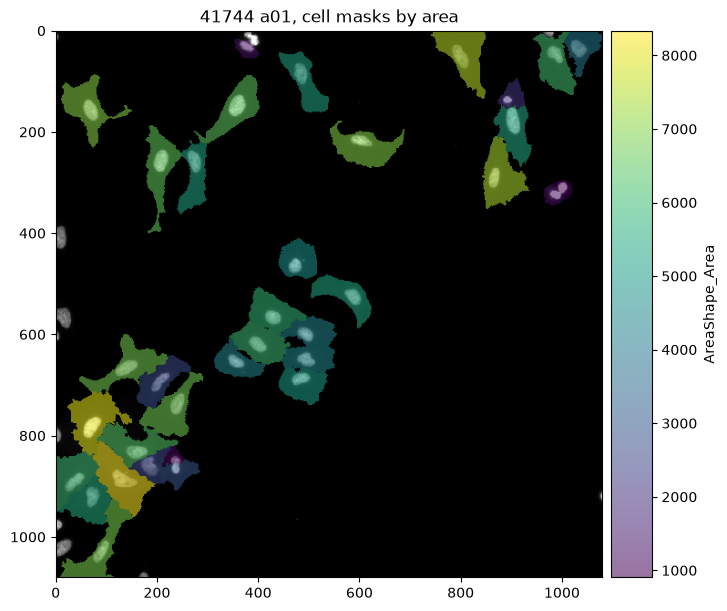

In [4]:
element = f"{PLATE}_a01_s1_image"
(
    sdata.pl.render_images(element, **grey(sdata, element))
    .pl.render_labels(f"{PLATE}_a01_s1_cells", color="AreaShape_Area", table_name="cells", fill_alpha=0.55)
    .pl.show(coordinate_systems=f"{PLATE}_a01_s1", figsize=(6.5, 6), title=f"{PLATE} a01, cell masks by area")
)